# Exploring the similarity space

This notebook will be used to explore what the resulting similarity space represents. In particular, I will examine whether books cluster by genre, whether there are unusual outliers, and whether the embedding space shows any clear structure or is instead a relatively diffuse cloud.

I will start with PCA (Principal Component Analysis), which identifies the directions of greatest variance in the data and projects the embeddings onto the two principal components. PCA is deterministic and computationally efficient, and the two axes are mathematically meaningful: each component captures as much variance as possible while remaining orthogonal to the preceding components.

## PCA

In [3]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

BOOK_ID_PATH = "/home/claraoberle/personal-book-recommender/data/embedding/book_ids.npy"
EMBEDDINGD_PATH = "/home/claraoberle/personal-book-recommender/data/embedding/embeddings.npy"
CLEAN_DF_PATH = "/home/claraoberle/personal-book-recommender/data/clean/goodreads_clean.csv"

In [4]:
book_ids = np.load(BOOK_ID_PATH, allow_pickle=True)
embeddings = np.load(EMBEDDINGD_PATH, allow_pickle=True)
clean_df = pd.read_csv(CLEAN_DF_PATH)

In [5]:
# Project embeddings into 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Create dataframe with the PCA coordinates
pca_df = pd.DataFrame(embeddings_2d, columns=["PC1", "PC2"])

# Add Book Id
pca_df["Book Id"] = book_ids.astype(str)

# Add ratings from Goodreads
clean_df["Book Id"] = clean_df["Book Id"].astype(str)

pca_df = pca_df.merge(clean_df[["Book Id", "My Rating", "Title"]], on="Book Id", how="left")

In [6]:
pca_df.head()

,PC1,PC2,Book Id,My Rating,Title
0,-0.281326,0.515788,222947,0.0,La comunidad del anillo (El señor de los anill...
1,0.336403,-0.222180,55659629,2.0,"It Happened One Summer (Bellinger Sisters, #1)"
2,-0.174433,-0.253874,54438718,4.0,Una promesa de juventud
3,0.346662,-0.025809,22628,5.0,The Perks of Being a Wallflower
4,0.021666,-0.184612,36336078,3.0,"Call Me By Your Name (Call Me By Your Name, #1)"


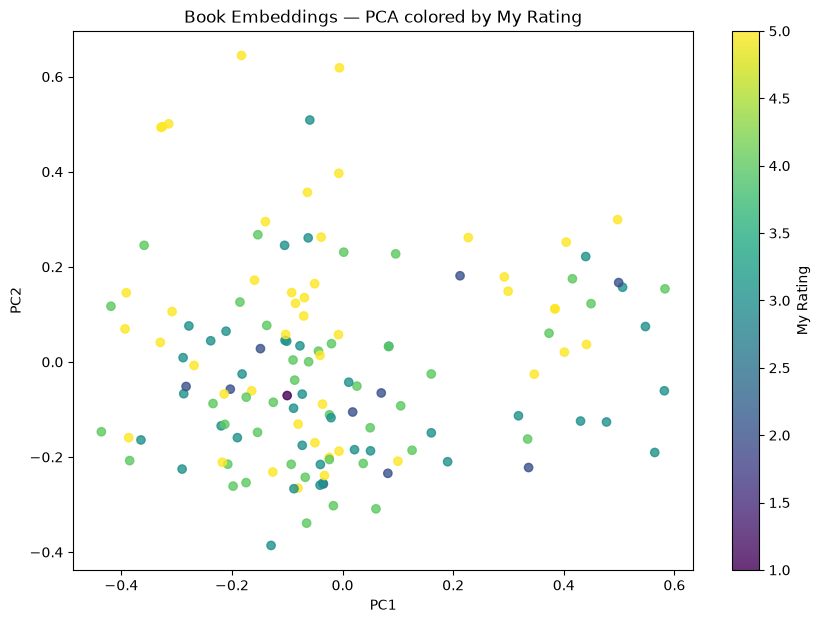

In [7]:
# since 0.0 in goodreads means not rated, we exclude those books
rated = pca_df[pca_df["My Rating"] > 0]

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    rated["PC1"],
    rated["PC2"],
    c=rated["My Rating"],
    cmap="viridis",
    alpha=0.8
)

plt.colorbar(scatter, label="My Rating")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Book Embeddings — PCA colored by My Rating")

plt.savefig("/home/claraoberle/personal-book-recommender/data/output/PCA colored by My Rating.png")
plt.show()


The plot shows no clear relationship between rating and position in the embedding space. High- and low-rated books are scattered throughout, with no distinct region corresponding to higher ratings. This suggests that content similarity and personal preference are different axes: the embedding captures what kind of book it is, while the rating captures whether I personally liked it. This supports the need for a separate rating-based taste vector to represent my preferences.

In [8]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.08804344 0.05833402]
0.14637746


The top 2 principal components only capture around 15% of the total variance in the 384-dimensional space. The plot is showing only a small, possibly unrepresentative part of the actual structure.

## Pairwise similarity histogram

Now I will plot a pairwise similarity histogram, which works directly on the original 384-dimensional embeddings. It tells much more directly whether books are actually close/far apart in embedding space.

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate pairwise cosine similarity between all books
similarities = cosine_similarity(embeddings)

# Get only the upper triangle, excluding the diagonal
# (avoids counting each pair twice and ignores similarity of a book with itself)
upper_triangle = np.triu_indices_from(similarities, k=1)
pairwise_similarities = similarities[upper_triangle]

In [10]:
pairwise_similarities.shape

(16471,)

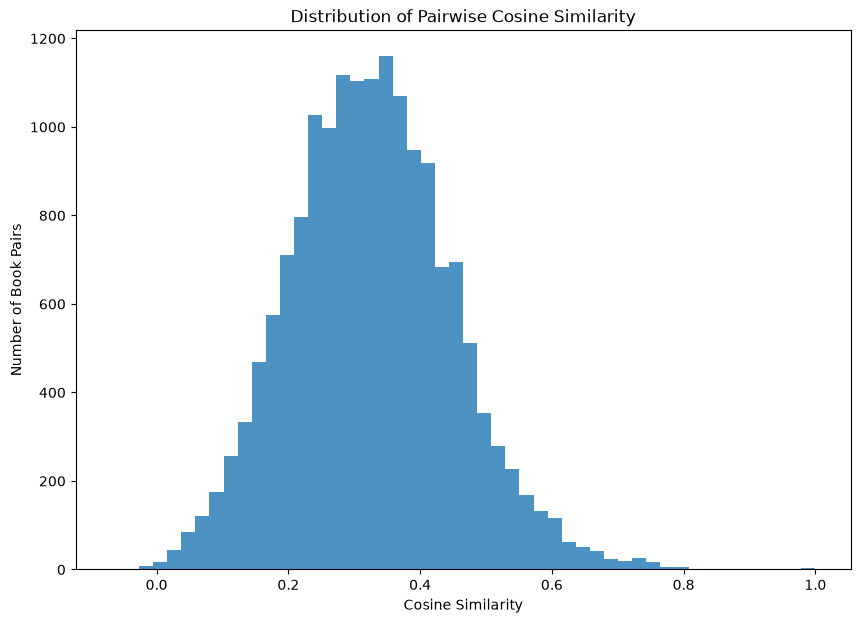

In [12]:
plt.figure(figsize=(10, 7))

plt.hist(pairwise_similarities, bins=50, alpha=0.8)

plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Book Pairs")
plt.title("Distribution of Pairwise Cosine Similarity")

plt.savefig("/home/claraoberle/personal-book-recommender/data/output/Pairwise Similarity Histogram.png")

plt.show()

The distribution is unimodal and roughly bell-shaped, centered around 0.32–0.33, with a standard deviation of 0.124. Most book pairs share moderate, generic thematic overlap, which is exactly what you'd expect from a diverse personal library rather than a single-genre collection. The right tail thinning out past ~0.55 is the important part: this confirms the earlier spot-checks like Hunger Games/Catching Fire at 0.69 and LOTR's fantasy neighbors around 0.54–0.61 sit meaningfully out in that tail, not near the 0.32 average. A 0.5+ similarity in this space really does mean "unusually alike," not just noise. That gives a concrete number to calibrate against later: when I rank to-read candidates against my taste vector, a 0.4 similarity is roughly "typical" and a 0.6+ is genuinely standing out.

In [11]:
print(f"Number of books: {len(embeddings)}")
print(f"Number of unique book pairs: {len(pairwise_similarities):,}")

print(f"Mean similarity: {pairwise_similarities.mean():.3f}")
print(f"Median similarity: {np.median(pairwise_similarities):.3f}")
print(f"Minimum similarity: {pairwise_similarities.min():.3f}")
print(f"Maximum similarity: {pairwise_similarities.max():.3f}")
print(f"Standard deviation: {pairwise_similarities.std():.3f}")

Number of books: 182
Number of unique book pairs: 16,471
Mean similarity: 0.327
Median similarity: 0.323
Minimum similarity: -0.069
Maximum similarity: 1.000
Standard deviation: 0.124


The maximum similarity is exactly 1.000, which means two distinct books in my library have identical embedding vectors, that only happens with identical or near-identical input text. I'll check to make sure no duplicates slipped by.

In [13]:
# Get indices of the pair with the highest similarity
max_idx = np.argmax(pairwise_similarities)

book_idx_1 = upper_triangle[0][max_idx]
book_idx_2 = upper_triangle[1][max_idx]

# Get the Book IDs
book_id_1 = book_ids[book_idx_1]
book_id_2 = book_ids[book_idx_2]

# Get the book information from clean_df
book_1 = clean_df.loc[clean_df["Book Id"] == str(book_id_1), ["Book Id", "Title"]]

book_2 = clean_df.loc[clean_df["Book Id"] == str(book_id_2), ["Book Id", "Title"]]

print(f"Similarity: {pairwise_similarities[max_idx]:.6f}")
print("\nBook 1:")
print(book_1)

print("\nBook 2:")
print(book_2)

Similarity: 1.000000

Book 1:
   Book Id                                           Title
71   62291  A Storm of Swords (A Song of Ice and Fire, #3)

Book 2:
   Book Id                                           Title
72   10572  A Clash of Kings  (A Song of Ice and Fire, #2)


Since these books belong to the same saga, it is reasonable that they have ended up with the same embedding vector. The most likely cause is that there's barely any embedding text, or they have very similar descriptions and categories.